In [1]:
print(5+5)

10


In [2]:
import sys
sys.path.append('../../datasets')
#from spark_utils import *
import getpass
import pathlib
import os
import io
from tqdm import tqdm
from optuna.samplers import TPESampler
#import datadicts as dd
import pathlib
import sys
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import sklearn
import catboost as cb
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn import metrics
import optuna
import shap
#from optuna.samplers import TPESampler
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix, precision_recall_curve, roc_curve
import warnings
warnings.filterwarnings('ignore')

import pickle

from sklearn.preprocessing import LabelEncoder

/opt/user-venvs/python3.8/lib64/python3.8/site-packages/shap/utils/_clustering.py:35: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def _pt_shuffle_rec(i, indexes, index_mask, partition_tree, M, pos):
/opt/user-venvs/python3.8/lib64/python3.8/site-packages/shap/utils/_clustering.py:54: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def delta_minimization_order(al

In [3]:
import logging
import pandas as pd
from tqdm import tqdm

logging.basicConfig(level=logging.INFO, format='[%(asctime)s %(levelname)s - %(message)s]')

def normalize_column_names(data):
    logging.info("Приведение колонок к нижнему регистру")
    rename_map = {col: col.lower() for col in data.columns if col != col.lower()}
    return data.rename(columns=rename_map)

def remove_bad_columns(data):
    logging.info("Удаление плохих признаков")
    bad_columns = []
    
    # Исключаем epk_id из удаляемых колонок
    id_columns = list(filter(lambda x: x[-3:] in ["_id", "_dk"], data.columns))
    id_columns = [col for col in id_columns if col not in ["epk_id"]]  # сохраняем epk_id
    bad_columns += id_columns
    
    bad_columns += list(filter(lambda x: x[:4] in ["act"], data.columns))
    bad_columns += [col for col in data.columns if '_oi_' in col]
    
    bad_columns += [
          "ctl_loading"
        , "row_upd_dttm"
        , "prl_tax_payer_inn"
        , "prl_agrmnt_nbr"
        , "dep_payroll_bitmask_l12m_cd"
        , "dep_social_bitmask_l12m_cd"
        , "crd_lst_agrmnt_vsp_cd"
        , "crd_lst_agrmnt_osb_cd"
        , "prd_lst_prod_osb_cd"
        , 'birth_dt'
        , 'sd_age_mnth_comp_nv'            
        , 'sd_age_yrs_comp_nv'
        , 'data_type'
        , 'type'
        , 'sd_age_yrs_comp_nv'
        , 'crd_lst_agrmnt_tb_cd'
        , 'prl_tbholding_id'
        , 'dep_lst_payroll_agrmnt_id'
        , 'dep_acct_1st_division_dk'
        , 'dep_acct_lst_division_dk'
        , 'dep_acct_max_bal_division_dk'
        , 'prd_1st_prod_division_dk'
        , 'prd_lst_prod_division_dk'
        , 'seg_main_card_dwh_id'
        , 'tp_lst_division_dk'
        , 'crd_cc_lst_plastic_type_id'
        , 'crd_dc_lst_plastic_type_id'
        , 'prd_lst_prod_vsp_cd'
        , 'seg_crd_pos_cat_group'
        , 'seg_crm_segment_cd'
        , 'seg_client_cx_segment_cd'
        , 'seg_client_cx_criteria'
        , 'prl_tax_payer_inn'
        , 'prd_1st_prod_division_dk'
        , 'tp_lst_tb_cd'
        , 'tp_lst_kind_cd'
        , 'sd_dead_nflag'
    ]
    
    # Исключаем report_dt из удаляемых колонок
    if "report_dt" in bad_columns:
        bad_columns.remove("report_dt")
    
    bad_columns = list(set(bad_columns))
    bad_columns = [col for col in bad_columns if col in data.columns]
    
    logging.info(f"Удалено {len(bad_columns)} колонок: {bad_columns}")
    return data.drop(columns=bad_columns, errors="coerce")

def process_date_columns(data, report_col="report_dt"):
    logging.info("Преобразование datetime колонок в 'дни до report_dt'")
    
    if report_col not in data.columns:
        logging.warning(f"Колонка {report_col} отсутствует в данных")
        return data
    
    # Преобразуем report_dt в datetime
    data[report_col] = pd.to_datetime(data[report_col].astype(str), errors="coerce")
    
    # Находим все датовые колонки, исключая report_dt
    date_cols = [col for col in data.columns if "_dt" in col and col != report_col]
    
    # Также можно добавить другие колонки с датами по названию
    date_keywords = ['_date', '_dttm', '_time']
    for keyword in date_keywords:
        date_cols += [col for col in data.columns if keyword in col and col not in date_cols and col != report_col]
    
    date_cols = list(set(date_cols))
    
    logging.info(f"Найдено {len(date_cols)} датовых колонок для обработки")
    
    for col in tqdm(date_cols, desc="Обработка дат"):
        data[col] = pd.to_datetime(data[col].astype(str), errors="coerce")
        # Преобразуем в количество дней до report_dt
        data[col] = (data[report_col] - data[col]).dt.days
    
    # НЕ удаляем report_dt - просто возвращаем данные с этой колонкой
    return data

def fill_missing_values(data):
    # Теперь исключаем epk_id и report_dt из заполнения
    EXCLUDED_COLS = ["report_dt", "epk_id"]
    
    logging.info("Заполнение пропусков")
    fill_config = {
        "flg":               {"fill": -1,   "type": "int32"},
        "_qty":              {"fill": -999999},
        "_pct":              {"fill": -999999},
        "_days":             {"fill": -999999},
        "_num":              {"fill": -999999},
        "_amt":              {"fill": -999999},
        "_prc":              {"fill": -999999},
        "_rate":             {"fill": -999999,   "type": "float64"},
        "_frac":             {"fill": -999999,   "type": "float64"},
        "_nflag":            {"fill": -999999,   "type": "float64"},
        "_dt":               {"fill": -999999,   "type": "float64"},
        "float64":           {"fill": -999999},
        "int32":             {"fill": -999999},
        "object":            {"fill": 'UNKNOWN'}
    }
   
    for col in tqdm(data.columns, desc="Заполнение пропусков"):
        if col in EXCLUDED_COLS:
            continue
        
        col_handled = False
       
        for pattern, rule in fill_config.items():
            if pattern in col:
                fill_val = rule["fill"]
                dtype = rule.get("type", None)
                data[col] = data[col].fillna(fill_val)
                if dtype:
                    data[col] = data[col].astype(dtype)
                col_handled = True
                break
               
        if not col_handled:
            col_type = str(data[col].dtype)
            if col_type in fill_config:
                fill_val = fill_config[col_type]["fill"]
                dtype = fill_config[col_type].get("type", None)
                data[col] = data[col].fillna(fill_val)
                if dtype:
                    data[col] = data[col].astype(dtype)
                   
    return data

def preprocess(data):
    logging.info("Старт предобработки")
    data = normalize_column_names(data)
    data = remove_bad_columns(data)
    data = process_date_columns(data, report_col="report_dt")
    data = fill_missing_values(data)
    cat_features = data.select_dtypes(include="object").columns.tolist()
    
    # Проверяем, что нужные колонки сохранились
    if "epk_id" not in data.columns:
        logging.warning("Колонка epk_id не найдена после предобработки!")
    if "report_dt" not in data.columns:
        logging.warning("Колонка report_dt не найдена после предобработки!")
    
    logging.info(f"Предобработка завершена. Число признаков: {data.shape[1]}")
    logging.info(f"Колонки сохранены: epk_id={'epk_id' in data.columns}, report_dt={'report_dt' in data.columns}")
    
    return data, cat_features

def prepare_dataset(train_df):
    logging.info("=== Запуск подготовки датасетов ===")
    train_df, cat_features = preprocess(train_df)
    logging.info(f"=== Подготовка завершена. Число признаков: {train_df.shape[1]} ===")
    return train_df, cat_features


In [4]:
def remove_corelated_features(df, threshold = 0.97, method = 'pearson'):
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    non_numeric_cols = df.columns.difference(numeric_cols).tolist()
    
    if not numeric_cols:
        return df
    
    corr_matrix = df[numeric_cols].corr(method = method).abs()
    parent = {}
    def find(u):
        while parent[u] != u:
            parent[u] = parent[parent[u]]
            u = parent[u]
        return u
    
    def union(u, v):
        root_u = find(u)
        root_v = find(v)
        if root_u != root_v:
            parent[root_v] = root_u
    
    for col in numeric_cols:
        parent[col] = col
        
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] > threshold:
                col_i = corr_matrix.columns[i]
                col_j = corr_matrix.columns[j]
                union(col_i, col_j)
                
    groups = {}
    for col in numeric_cols:
        root = find(col)
        if root not in groups:
            groups[root] = []
        groups[root].append(col)
    
    selected = []
    for group in groups.values():
        best = max(group, key = lambda x: corr_matrix[x].sum())
        selected.append(best)
    
    result_cols = non_numeric_cols + selected
    
    result_cols = list(dict.fromkeys(result_cols))
    
    return result_cols

In [5]:
def cat_fi(model):
    cat_fi = pd.Series(
    data=model.feature_importances_,
    index=model.feature_names_,
    )
    fi = pd.DataFrame({"catboost_importance": cat_fi}).reset_index().sort_values(by = "catboost_importance", ascending = False)
    fi = fi.reset_index(drop = True)
    fi["desc"] = fi["index"].map(dd.FT_CLIENT_AGGR_MNTH)
    return fi

In [6]:
!hdfs dfs -get hdfs://arnsdpsbx/user/team/team_ss/bpm_premier_multiclass_v3_new_all_features_fix_types_train_for_model

Picked up JAVA_TOOL_OPTIONS: -XX:ThreadStackSize=4096 -XX:VMThreadStackSize=4096


In [204]:
!hdfs dfs -get hdfs://arnsdpsbx/user/team/team_ss/bpm_premier_multiclass_v4_oot_model_fixed_new

Picked up JAVA_TOOL_OPTIONS: -XX:ThreadStackSize=4096 -XX:VMThreadStackSize=4096


In [205]:
df = pd.read_parquet('bpm_premier_multiclass_v4_oot_model_fixed_new')

In [7]:
df = pd.read_parquet('bpm_premier_multiclass_v3_new_all_features_fix_types_train_for_model')

In [9]:
columns_to_drop = [col for col in df.columns if col.startswith('emb')]

df = df.drop(columns=columns_to_drop)

In [11]:
sample = df.sample(n=50000) 
cols = list(sample.columns)
feats = remove_corelated_features(sample[cols], threshold=0.97)

In [12]:
train_df = df[feats]

In [13]:
train_df.to_parquet('df_without_corr_v2.parquet')

In [14]:
train_df, cat_features = prepare_dataset(train_df)

[2026-03-19 06:38:59,582 INFO - === Запуск подготовки датасетов ===]
[2026-03-19 06:38:59,583 INFO - Старт предобработки]
[2026-03-19 06:38:59,584 INFO - Приведение колонок к нижнему регистру]
[2026-03-19 06:39:02,732 INFO - Удаление плохих признаков]
[2026-03-19 06:39:02,734 INFO - Удалено 31 колонок: ['prd_1st_prod_division_dk', 'prl_subholding_id', 'pnl_oi_pl_amt_12m', 'seg_client_cx_segment_cd', 'tp_lst_tb_cd', 'prl_holding_id', 'dep_acct_max_bal_division_dk', 'seg_crm_segment_cd', 'crd_lst_agrmnt_tb_cd', 'prl_tax_payer_inn', 'row_upd_dttm', 'tp_lst_division_dk', 'dep_acct_1st_division_dk', 'seg_main_card_dwh_id', 'actual_epk_id', 'pnl_oi_pl_amt', 'prd_lst_prod_vsp_cd', 'seg_client_cx_criteria', 'tp_lst_kind_cd', 'prd_lst_prod_osb_cd', 'crd_lst_agrmnt_vsp_cd', 'prl_tbholding_id', 'crd_lst_agrmnt_osb_cd', 'dep_payroll_bitmask_l12m_cd', 'dep_social_bitmask_l12m_cd', 'sd_dead_nflag', 'seg_crd_pos_cat_group', 'dep_acct_lst_division_dk', 'prl_agrmnt_nbr', 'dep_lst_payroll_agrmnt_id', 'p

In [207]:
train_df, cat_features = prepare_dataset(df)

[2026-03-19 11:31:02,905 INFO - === Запуск подготовки датасетов ===]
[2026-03-19 11:31:02,906 INFO - Старт предобработки]
[2026-03-19 11:31:02,906 INFO - Приведение колонок к нижнему регистру]
[2026-03-19 11:31:03,399 INFO - Удаление плохих признаков]
[2026-03-19 11:31:03,400 INFO - Удалено 0 колонок: []]
[2026-03-19 11:31:03,925 INFO - Преобразование datetime колонок в 'дни до report_dt']
[2026-03-19 11:31:04,052 INFO - Найдено 21 датовых колонок для обработки]
Обработка дат: 100%|██████████| 21/21 [00:06<00:00,  3.14it/s]
[2026-03-19 11:31:10,736 INFO - Заполнение пропусков]
Заполнение пропусков: 100%|██████████| 34/34 [00:00<00:00, 52.34it/s]
[2026-03-19 11:31:11,452 INFO - Предобработка завершена. Число признаков: 34]
[2026-03-19 11:31:11,452 INFO - Колонки сохранены: epk_id=True, report_dt=True]
[2026-03-19 11:31:11,453 INFO - === Подготовка завершена. Число признаков: 34 ===]


In [208]:
train_df.to_parquet('prep_data_v3_oot_new.parquet')

In [15]:
train_df.to_parquet('prep_data_v3_new.parquet')

In [16]:
cols = df[['epk_id']]
final_df = pd.concat([cols, train_df], axis=1)

In [18]:
cols_to_move = ['epk_id', 'report_dt', 'mon', 'target']
final_df = final_df[cols_to_move + [c for c in final_df.columns if c not in cols_to_move]]

In [19]:
final_df.duplicated().sum()

0

In [20]:
final_df.to_parquet('final_v3_new.parquet')

In [21]:
final_df = pd.read_parquet('final_v3_new.parquet')

# Catboost

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import re
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
pd.set_option('Display.max_columns', None)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
import sys
import gc
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
from sklearn.feature_selection import SequentialFeatureSelector as SFS
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance 
from catboost import CatBoostClassifier
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score
from sklearn.preprocessing import LabelBinarizer, LabelEncoder
from sklearn.model_selection import train_test_split
import catboost as ctb
from typing import Union
import optuna 
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix, precision_recall_curve, roc_curve, classification_report
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from catboost import Pool

In [137]:
x = final_df.drop(columns=['target', 'mon', 'report_dt', 'epk_id'])
y = final_df['target']

In [138]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size = 0.25, random_state = 0)

In [26]:
text_columns = x_train.select_dtypes(include=['object']).columns.tolist()

In [27]:
with open ('features_dict.pkl', 'rb') as f:
    feature_names = pickle.load(f)
    
from catboost import Pool

In [28]:
def get_pool(target_column = 'target', features = None):
    features = train.columns.tolist() if features is None else features
    categorical_columns = train[features].select_dtypes('object').columns.tolist()
    
    train_pool = ctb.Pool(data = train[features].drop(target_column, axis = 1, errors = 'ignore'), label = train[target_column], cat_features = categorical_columns)
    val_pool  = ctb.Pool(data = val[features].drop(target_column, axis = 1, errors = 'ignore'), label = val[target_column],  cat_features = categorical_columns)
    test_pool  = ctb.Pool(data = test[features].drop(target_column, axis = 1, errors = 'ignore'), label = test[target_column],  cat_features = categorical_columns)
    
    return train_pool, val_pool, test_pool

def show_importances(model : Union[ctb.CatBoostClassifier, None], num : int = None) -> pd.DataFrame:
    importances = model.get_feature_importance(prettified=True)
    importances['Фичи'] = importances['Feature Id'].apply(lambda x: feature_names.get(x))
    if num:
        return importances.head(num)
    return importances.head(min(len(importances), 50))

## First iter

In [ ]:
srv_sbol_1st_login_dt,
srv_sbol_mob_1st_login_dt,
seg_service_channel_cd, prd_lst_prod_cd, tp_active_kind_cd, seg_premier_cd
seg_crd_segm_special_set_dt, seg_crd_segm_special_prev_cd, tp_best_kind_ever_cd, prd_lst_prod_tb_cd, prd_client_type_final_cd, tp_best_kind_ever_cd
seg_crd_segm_special_cd, seg_client_mp_segment_cd, tp_lst_grace_end_exp_dt
tp_1st_open_dt, seg_client_rb_segment_cd
seg_client_sb_segment_cd

In [139]:
x_train = x_train.drop(columns=['srv_sbol_1st_login_dt',
'srv_sbol_mob_1st_login_dt','seg_service_channel_cd', 'prd_lst_prod_cd', 'tp_active_kind_cd', 'seg_premier_cd', 'seg_crd_segm_special_set_dt', 'seg_crd_segm_special_prev_cd', 'tp_best_kind_ever_cd', 'prd_lst_prod_tb_cd', 'prd_client_type_final_cd', 'tp_best_kind_ever_cd', 'seg_crd_segm_special_cd', 'seg_client_mp_segment_cd', 'tp_lst_grace_end_exp_dt', 'tp_1st_open_dt', 'seg_client_rb_segment_cd', 'seg_client_sb_segment_cd'])
x_val = x_val.drop(columns=['srv_sbol_1st_login_dt',
'srv_sbol_mob_1st_login_dt','seg_service_channel_cd', 'prd_lst_prod_cd', 'tp_active_kind_cd', 'seg_premier_cd', 'seg_crd_segm_special_set_dt', 'seg_crd_segm_special_prev_cd', 'tp_best_kind_ever_cd', 'prd_lst_prod_tb_cd', 'prd_client_type_final_cd', 'tp_best_kind_ever_cd', 'seg_crd_segm_special_cd', 'seg_client_mp_segment_cd', 'tp_lst_grace_end_exp_dt', 'tp_1st_open_dt', 'seg_client_rb_segment_cd', 'seg_client_sb_segment_cd'])
x_test = x_test.drop(columns=['srv_sbol_1st_login_dt',
'srv_sbol_mob_1st_login_dt','seg_service_channel_cd', 'prd_lst_prod_cd', 'tp_active_kind_cd', 'seg_premier_cd', 'seg_crd_segm_special_set_dt', 'seg_crd_segm_special_prev_cd', 'tp_best_kind_ever_cd', 'prd_lst_prod_tb_cd', 'prd_client_type_final_cd', 'tp_best_kind_ever_cd', 'seg_crd_segm_special_cd', 'seg_client_mp_segment_cd', 'tp_lst_grace_end_exp_dt', 'tp_1st_open_dt', 'seg_client_rb_segment_cd', 'seg_client_sb_segment_cd'])

In [140]:
text_columns = x_train.select_dtypes(include=['object']).columns.tolist()

In [141]:
train_pool = Pool(x_train, y_train, cat_features=text_columns)
val_pool = Pool(x_val, y_val, cat_features=text_columns)
test_pool = Pool(x_test, y_test, cat_features=text_columns)

In [142]:
#class_weights = [1, 2, 1, 2, 1]
model = ctb.CatBoostClassifier(iterations=1000, depth=5, learning_rate = 0.1, 
                               verbose=100, task_type = 'GPU', loss_function='MultiClass',
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass')
model.fit(train_pool, eval_set = val_pool)

0:	learn: 1.4662923	test: 1.4667916	best: 1.4667916 (0)	total: 22.6ms	remaining: 22.6s
100:	learn: 0.8793503	test: 0.8829825	best: 0.8829825 (100)	total: 1.79s	remaining: 15.9s
200:	learn: 0.8567113	test: 0.8625445	best: 0.8625445 (200)	total: 3.55s	remaining: 14.1s
300:	learn: 0.8451809	test: 0.8530332	best: 0.8530332 (300)	total: 5.23s	remaining: 12.2s
400:	learn: 0.8381421	test: 0.8478793	best: 0.8478793 (400)	total: 6.86s	remaining: 10.3s
500:	learn: 0.8331326	test: 0.8446465	best: 0.8446465 (500)	total: 8.42s	remaining: 8.39s
600:	learn: 0.8293624	test: 0.8424740	best: 0.8424740 (600)	total: 9.96s	remaining: 6.61s
700:	learn: 0.8260246	test: 0.8406899	best: 0.8406899 (700)	total: 11.5s	remaining: 4.89s
800:	learn: 0.8232462	test: 0.8393877	best: 0.8393872 (799)	total: 12.9s	remaining: 3.21s
900:	learn: 0.8209317	test: 0.8383313	best: 0.8383313 (900)	total: 14.4s	remaining: 1.58s
999:	learn: 0.8189092	test: 0.8376084	best: 0.8376084 (999)	total: 15.8s	remaining: 0us
bestTest = 0.83

In [143]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'weighted')}")

TRAIN : 0.8556630515690143
VAL : 0.849432541063221
TEST : 0.8494277164722541


In [144]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'macro')}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'macro')}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'macro')}")

TRAIN : 0.8406945106870495
VAL : 0.8315506203438912
TEST : 0.8311382129309722


In [145]:
print(classification_report(y_test, model.predict(test_pool)))

              precision    recall  f1-score   support

           1       0.53      0.17      0.26     15911
           2       0.58      0.58      0.58     31277
           3       0.50      0.30      0.38      7998
           4       0.41      0.05      0.09      9561
           5       0.75      0.93      0.83     95253

    accuracy                           0.70    160000
   macro avg       0.56      0.41      0.43    160000
weighted avg       0.67      0.70      0.66    160000



In [147]:
importances = model.get_feature_importance(prettified=True)

In [148]:
a = importances.loc[importances['Importances'] > 0.01, 'Feature Id'].tolist()

In [149]:
len(a)

225

## Second iter

In [150]:
x_train_new = x_train[a]
x_val_new = x_val[a]
x_test_new = x_test[a]

In [151]:
text_columns = x_train_new.select_dtypes(include=['object']).columns.tolist()

In [152]:
train_pool = Pool(x_train_new, y_train, cat_features=text_columns)
val_pool = Pool(x_val_new, y_val, cat_features=text_columns)
test_pool = Pool(x_test_new, y_test, cat_features=text_columns)

In [153]:
model = ctb.CatBoostClassifier(iterations=1000, depth=5, learning_rate = 0.1, 
                               verbose=100, task_type = 'GPU', loss_function='MultiClass',
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass')
model.fit(train_pool, eval_set = val_pool)

0:	learn: 1.4662926	test: 1.4667920	best: 1.4667920 (0)	total: 14.7ms	remaining: 14.6s
100:	learn: 0.8793498	test: 0.8829822	best: 0.8829822 (100)	total: 1.24s	remaining: 11s
200:	learn: 0.8567113	test: 0.8625446	best: 0.8625446 (200)	total: 2.41s	remaining: 9.59s
300:	learn: 0.8454251	test: 0.8533069	best: 0.8533069 (300)	total: 3.56s	remaining: 8.27s
400:	learn: 0.8376669	test: 0.8475050	best: 0.8475050 (400)	total: 4.72s	remaining: 7.05s
500:	learn: 0.8318221	test: 0.8435802	best: 0.8435802 (500)	total: 5.88s	remaining: 5.85s
600:	learn: 0.8276868	test: 0.8413582	best: 0.8413582 (600)	total: 6.99s	remaining: 4.64s
700:	learn: 0.8241781	test: 0.8396396	best: 0.8396396 (700)	total: 8.1s	remaining: 3.46s
800:	learn: 0.8210301	test: 0.8381679	best: 0.8381679 (800)	total: 9.22s	remaining: 2.29s
900:	learn: 0.8182327	test: 0.8369519	best: 0.8369519 (900)	total: 10.3s	remaining: 1.13s
999:	learn: 0.8156314	test: 0.8359680	best: 0.8359680 (999)	total: 11.4s	remaining: 0us
bestTest = 0.83596

In [154]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'weighted')}")

TRAIN : 0.8567656359528577
VAL : 0.8500395022023746
TEST : 0.8500781385914342


In [155]:
print(classification_report(y_test, model.predict(test_pool)))

              precision    recall  f1-score   support

           1       0.53      0.17      0.26     15911
           2       0.59      0.58      0.58     31277
           3       0.50      0.30      0.37      7998
           4       0.41      0.05      0.09      9561
           5       0.76      0.93      0.83     95253

    accuracy                           0.70    160000
   macro avg       0.56      0.41      0.43    160000
weighted avg       0.67      0.70      0.66    160000



## Third iter 

In [156]:
model = ctb.CatBoostClassifier(iterations=1000, depth=5, learning_rate = 0.1, 
                               verbose=100, task_type = 'GPU', loss_function='MultiClass',
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass')

summary = model.select_features(train_pool, eval_set = val_pool,
                                features_for_select = x_train_new.drop('target', axis = 1, errors = 'ignore').columns.tolist(), 
                                steps = 5, 
                                verbose = 0,
                                num_features_to_select=50)


best_features = summary['selected_features_names']

CatBoost is using more CPU RAM (98.5GiB) than the limit (29.5GiB)
CatBoost is using more CPU RAM (98.5GiB) than the limit (29.5GiB)


Step #1 out of 5
bestTest = 0.836172168
bestIteration = 999
Feature #198 eliminated
Feature #182 eliminated
Feature #211 eliminated
Feature #197 eliminated
Feature #204 eliminated
Feature #195 eliminated
Feature #73 eliminated
Feature #215 eliminated
Feature #206 eliminated
Feature #179 eliminated
Feature #212 eliminated
Feature #194 eliminated
Feature #177 eliminated
Feature #209 eliminated
Feature #203 eliminated
Feature #205 eliminated
Feature #149 eliminated
Feature #210 eliminated
Feature #218 eliminated
Feature #167 eliminated
Feature #217 eliminated
Feature #180 eliminated
Feature #216 eliminated
Feature #200 eliminated
Feature #191 eliminated
Feature #214 eliminated
Feature #166 eliminated
Feature #220 eliminated
Feature #157 eliminated
Feature #221 eliminated
Feature #213 eliminated
Feature #224 eliminated
Feature #138 eliminated
Feature #184 eliminated
Feature #208 eliminated
Feature #190 eliminated
Feature #174 eliminated
Feature #175 eliminated
Feature #130 eliminated
Featu

CatBoost is using more CPU RAM (98.8GiB) than the limit (29.2GiB)
CatBoost is using more CPU RAM (98.8GiB) than the limit (29.2GiB)


bestTest = 0.835347168
bestIteration = 999
Feature #163 eliminated
Feature #143 eliminated
Feature #176 eliminated
Feature #61 eliminated
Feature #151 eliminated
Feature #165 eliminated
Feature #148 eliminated
Feature #131 eliminated
Feature #222 eliminated
Feature #192 eliminated
Feature #156 eliminated
Feature #132 eliminated
Feature #144 eliminated
Feature #170 eliminated
Feature #91 eliminated
Feature #150 eliminated
Feature #160 eliminated
Feature #161 eliminated
Feature #123 eliminated
Feature #133 eliminated
Feature #110 eliminated
Feature #115 eliminated
Feature #172 eliminated
Feature #142 eliminated
Feature #193 eliminated
Feature #121 eliminated
Feature #86 eliminated
Feature #223 eliminated
Feature #178 eliminated
Feature #140 eliminated
Feature #154 eliminated
Feature #107 eliminated
Feature #181 eliminated
Feature #186 eliminated
Feature #99 eliminated
Feature #119 eliminated
Feature #146 eliminated
Feature #104 eliminated
Feature #141 eliminated
Feature #122 eliminated
F

CatBoost is using more CPU RAM (99GiB) than the limit (29GiB)
CatBoost is using more CPU RAM (99GiB) than the limit (29GiB)


...

bestTest = 0.8356019531
bestIteration = 999
Feature #100 eliminated
Feature #74 eliminated
Feature #128 eliminated
Feature #135 eliminated
Feature #80 eliminated
Feature #118 eliminated
Feature #102 eliminated
Feature #113 eliminated
Feature #79 eliminated
Feature #98 eliminated
Feature #72 eliminated
Feature #78 eliminated
Feature #87 eliminated
Feature #37 eliminated
Feature #77 eliminated
Feature #136 eliminated
Feature #84 eliminated
Feature #57 eliminated
Feature #82 eliminated
Feature #89 eliminated
Feature #33 eliminated
Feature #71 eliminated
Feature #58 eliminated
Step #5 out of 5


CatBoost is using more CPU RAM (99GiB) than the limit (29GiB)
CatBoost is using more CPU RAM (99GiB) than the limit (29GiB)


bestTest = 0.8373668945
bestIteration = 999
Feature #42 eliminated
Feature #41 eliminated
Feature #43 eliminated
Feature #34 eliminated
Feature #75 eliminated
Feature #54 eliminated
Feature #39 eliminated
Feature #53 eliminated
Feature #68 eliminated
Feature #70 eliminated
Feature #63 eliminated
Feature #35 eliminated
Feature #95 eliminated
Feature #67 eliminated
Feature #93 eliminated
Feature #92 eliminated
Feature #101 eliminated
Feature #76 eliminated
Train final model


CatBoost is using more CPU RAM (99GiB) than the limit (29GiB)
CatBoost is using more CPU RAM (99GiB) than the limit (29GiB)


bestTest = 0.8423626953
bestIteration = 998
Shrink model to first 999 iterations.


In [157]:
best_features

['srv_sbol_1st_txn_dt',
 'cla_dep_active_last_dt',
 'cla_da_active_last_dt',
 'seg_client_fl_segment_cd',
 'srv_sbol_1st_login_ever_dt',
 'dep_acc_lst_open_dt',
 'dep_inf_new_acct_qty_sum_9_12',
 'crd_dc_lst_crd_1st_spnd_dt',
 'dep_payroll_max_dt',
 'srv_mb_1st_txn_ever_dt',
 'lne_pl_max_psb_trm_mnth_qty',
 'crd_inf_cc_total_rub_amt_sum_6m',
 'sd_russian_citizen_nflag',
 'dep_payroll_min_dt',
 'seg_age_segment',
 'srv_sbol_mob_3m_login_nflag',
 'cla_mb_active_last_dt',
 'prd_p2p_active_nflag',
 'cla_crd_cc_active_last_dt',
 'bal_ops_amt',
 'dep_inf_social_rub_amt_sum_6_9',
 'dep_social_min_dt',
 'crd_cc_max_issue_dt',
 'cla_curr_acc_active_last_dt',
 'prd_lst_prod_open_dt',
 'sd_name_age_segment_cd',
 'dep_social_max_dt',
 'srv_sbol_mob_lst_login_dt',
 'sd_resident_nflag',
 'tp_lst_open_dt',
 'segments_loy_parfum_pos_12m',
 'crd_otf_loan_qty_sum_12m',
 'srv_sbol_web_lst_login_ever_dt',
 'lne_act_pl_os_rub_amt',
 'srv_thanks_dt',
 'seg_crd_trx_segm',
 'crd_dc_lst_open_dt',
 'prd_invest_

In [158]:
x_train_new = x_train_new[best_features]
x_val_new = x_val_new[best_features]
x_test_new = x_test_new[best_features]

In [159]:
text_columns = x_train_new.select_dtypes(include=['object']).columns.tolist()

In [160]:
train_pool = Pool(x_train_new, y_train, cat_features=text_columns)
val_pool = Pool(x_val_new, y_val, cat_features=text_columns)
test_pool = Pool(x_test_new, y_test, cat_features=text_columns)

In [161]:
model = ctb.CatBoostClassifier(iterations=1000, depth=5, learning_rate = 0.1, 
                               verbose=100, task_type = 'GPU', loss_function='MultiClass',
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass')
model.fit(train_pool, eval_set = val_pool)

0:	learn: 1.4662927	test: 1.4667918	best: 1.4667918 (0)	total: 10.3ms	remaining: 10.3s
100:	learn: 0.8815861	test: 0.8850442	best: 0.8850442 (100)	total: 892ms	remaining: 7.94s
200:	learn: 0.8597706	test: 0.8651609	best: 0.8651609 (200)	total: 1.79s	remaining: 7.13s
300:	learn: 0.8488079	test: 0.8561353	best: 0.8561353 (300)	total: 2.65s	remaining: 6.16s
400:	learn: 0.8420634	test: 0.8512635	best: 0.8512635 (400)	total: 3.52s	remaining: 5.26s
500:	learn: 0.8366922	test: 0.8478293	best: 0.8478293 (500)	total: 4.45s	remaining: 4.43s
600:	learn: 0.8330530	test: 0.8460257	best: 0.8460257 (600)	total: 5.33s	remaining: 3.54s
700:	learn: 0.8297740	test: 0.8446179	best: 0.8446179 (700)	total: 6.19s	remaining: 2.64s
800:	learn: 0.8271214	test: 0.8436941	best: 0.8436941 (800)	total: 7.05s	remaining: 1.75s
900:	learn: 0.8248352	test: 0.8430498	best: 0.8430498 (900)	total: 7.91s	remaining: 869ms
999:	learn: 0.8225512	test: 0.8424473	best: 0.8424473 (999)	total: 8.74s	remaining: 0us
bestTest = 0.84

In [162]:
def simple_train(target_column = 'target', features = None, model_params = None):
    features = x_train.columns.tolist() if features is None else features
    categorical_columns = x_train[features].select_dtypes('object').columns.tolist()
    
    
    train_pool = ctb.Pool(data = x_train_new[features], label = y_train, cat_features = categorical_columns)
    val_pool  = ctb.Pool(data = x_val_new[features], label = y_val,  cat_features = categorical_columns)
    test_pool  = ctb.Pool(data = x_test_new[features], label = y_test,  cat_features = categorical_columns)

    model = ctb.CatBoostClassifier(iterations=1000, depth=5, learning_rate = 0.1, 
                               verbose=100, task_type = 'GPU', loss_function='MultiClass', 
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass')
        
    model.fit(train_pool, eval_set = val_pool)
    
    
    train_preds = model.predict(train_pool)
    train_probas = model.predict_proba(train_pool)
    
    val_preds = model.predict(val_pool)
    val_probas = model.predict_proba(val_pool)
    
    
    test_preds = model.predict(test_pool)
    test_probas = model.predict_proba(test_pool)
    
    
    
    return train_preds, train_probas, val_preds, val_probas, test_preds, test_probas, model

In [163]:
target_column = 'target' 
RANDOM_SEED = 0

train_roc_auc = []
val_roc_auc = []
test_roc_auc = []


train_f1 = []
val_f1 = []
test_f1 = []


importances  = show_importances(model, -1)['Feature Id'].tolist()

xticks = range(1, len(best_features), 3)

for num_features in tqdm(xticks):
    used_features = importances[: num_features]
    
    
    train_preds, train_probas, val_preds, val_probas, test_preds, test_probas, model_temp = simple_train(target_column, used_features)

    # train_f1.append(f1_score(train[target_column], train_preds))
    # val_f1.append(f1_score(val[target_column], val_preds))
    # test_f1.append(f1_score(test[target_column], test_preds))


    train_roc_auc.append(roc_auc_score(y_train, train_probas, multi_class = 'ovr', average = 'macro'))
    val_roc_auc.append(roc_auc_score(y_val, val_probas, multi_class = 'ovr', average = 'macro'))
    test_roc_auc.append(roc_auc_score(y_test, test_probas, multi_class = 'ovr', average = 'macro'))

  0%|          | 0/17 [00:00<?, ?it/s]

0:	learn: 1.4956107	test: 1.4960587	best: 1.4960587 (0)	total: 4.76ms	remaining: 4.76s
100:	learn: 1.1091836	test: 1.1123409	best: 1.1123374 (84)	total: 430ms	remaining: 3.82s
bestTest = 1.112337402
bestIteration = 84
Shrink model to first 85 iterations.


  6%|▌         | 1/17 [00:03<01:02,  3.93s/it]

0:	learn: 1.4672648	test: 1.4677354	best: 1.4677354 (0)	total: 8.67ms	remaining: 8.66s
100:	learn: 0.9680741	test: 0.9706224	best: 0.9706224 (100)	total: 781ms	remaining: 6.95s
200:	learn: 0.9635351	test: 0.9665756	best: 0.9665756 (200)	total: 1.54s	remaining: 6.12s
300:	learn: 0.9612551	test: 0.9648991	best: 0.9648991 (300)	total: 2.28s	remaining: 5.29s
400:	learn: 0.9594513	test: 0.9636437	best: 0.9636437 (400)	total: 3.04s	remaining: 4.54s
500:	learn: 0.9581762	test: 0.9628989	best: 0.9628989 (500)	total: 3.76s	remaining: 3.74s
600:	learn: 0.9570868	test: 0.9622838	best: 0.9622838 (600)	total: 4.46s	remaining: 2.96s
700:	learn: 0.9562572	test: 0.9618948	best: 0.9618948 (700)	total: 5.2s	remaining: 2.22s
800:	learn: 0.9555401	test: 0.9616063	best: 0.9616063 (800)	total: 5.93s	remaining: 1.47s
900:	learn: 0.9548609	test: 0.9613877	best: 0.9613877 (900)	total: 6.68s	remaining: 734ms
999:	learn: 0.9541817	test: 0.9611197	best: 0.9611197 (999)	total: 7.39s	remaining: 0us
bestTest = 0.961

 12%|█▏        | 2/17 [00:15<02:07,  8.52s/it]

...

 88%|████████▊ | 15/17 [03:08<00:27, 13.97s/it]

0:	learn: 1.4662923	test: 1.4667917	best: 1.4667917 (0)	total: 9.68ms	remaining: 9.67s
100:	learn: 0.8814049	test: 0.8848422	best: 0.8848422 (100)	total: 917ms	remaining: 8.16s
200:	learn: 0.8598161	test: 0.8652174	best: 0.8652174 (200)	total: 1.8s	remaining: 7.15s
300:	learn: 0.8492546	test: 0.8567700	best: 0.8567700 (300)	total: 2.65s	remaining: 6.16s
400:	learn: 0.8425693	test: 0.8520095	best: 0.8520095 (400)	total: 3.53s	remaining: 5.27s
500:	learn: 0.8378221	test: 0.8491769	best: 0.8491769 (500)	total: 4.39s	remaining: 4.37s
600:	learn: 0.8339439	test: 0.8471640	best: 0.8471640 (600)	total: 5.25s	remaining: 3.49s
700:	learn: 0.8308928	test: 0.8458905	best: 0.8458905 (700)	total: 6.12s	remaining: 2.61s
800:	learn: 0.8282988	test: 0.8449457	best: 0.8449457 (800)	total: 6.98s	remaining: 1.73s
900:	learn: 0.8258516	test: 0.8442043	best: 0.8442043 (900)	total: 7.85s	remaining: 863ms
999:	learn: 0.8235641	test: 0.8436402	best: 0.8436402 (999)	total: 8.66s	remaining: 0us
bestTest = 0.843

 94%|█████████▍| 16/17 [03:23<00:14, 14.10s/it]

0:	learn: 1.4662930	test: 1.4667914	best: 1.4667914 (0)	total: 9.94ms	remaining: 9.93s
100:	learn: 0.8815960	test: 0.8850021	best: 0.8850021 (100)	total: 908ms	remaining: 8.08s
200:	learn: 0.8595706	test: 0.8649508	best: 0.8649508 (200)	total: 1.83s	remaining: 7.26s
300:	learn: 0.8489285	test: 0.8564043	best: 0.8564043 (300)	total: 2.71s	remaining: 6.3s
400:	learn: 0.8421610	test: 0.8516251	best: 0.8516251 (400)	total: 3.59s	remaining: 5.36s
500:	learn: 0.8372392	test: 0.8485866	best: 0.8485866 (500)	total: 4.42s	remaining: 4.4s
600:	learn: 0.8333487	test: 0.8465714	best: 0.8465714 (600)	total: 5.29s	remaining: 3.52s
700:	learn: 0.8300501	test: 0.8451717	best: 0.8451717 (700)	total: 6.14s	remaining: 2.62s
800:	learn: 0.8273877	test: 0.8442424	best: 0.8442424 (800)	total: 7.01s	remaining: 1.74s
900:	learn: 0.8249176	test: 0.8434746	best: 0.8434746 (900)	total: 7.87s	remaining: 864ms
999:	learn: 0.8227469	test: 0.8429313	best: 0.8429313 (999)	total: 8.74s	remaining: 0us
bestTest = 0.8429

100%|██████████| 17/17 [03:37<00:00, 12.79s/it]


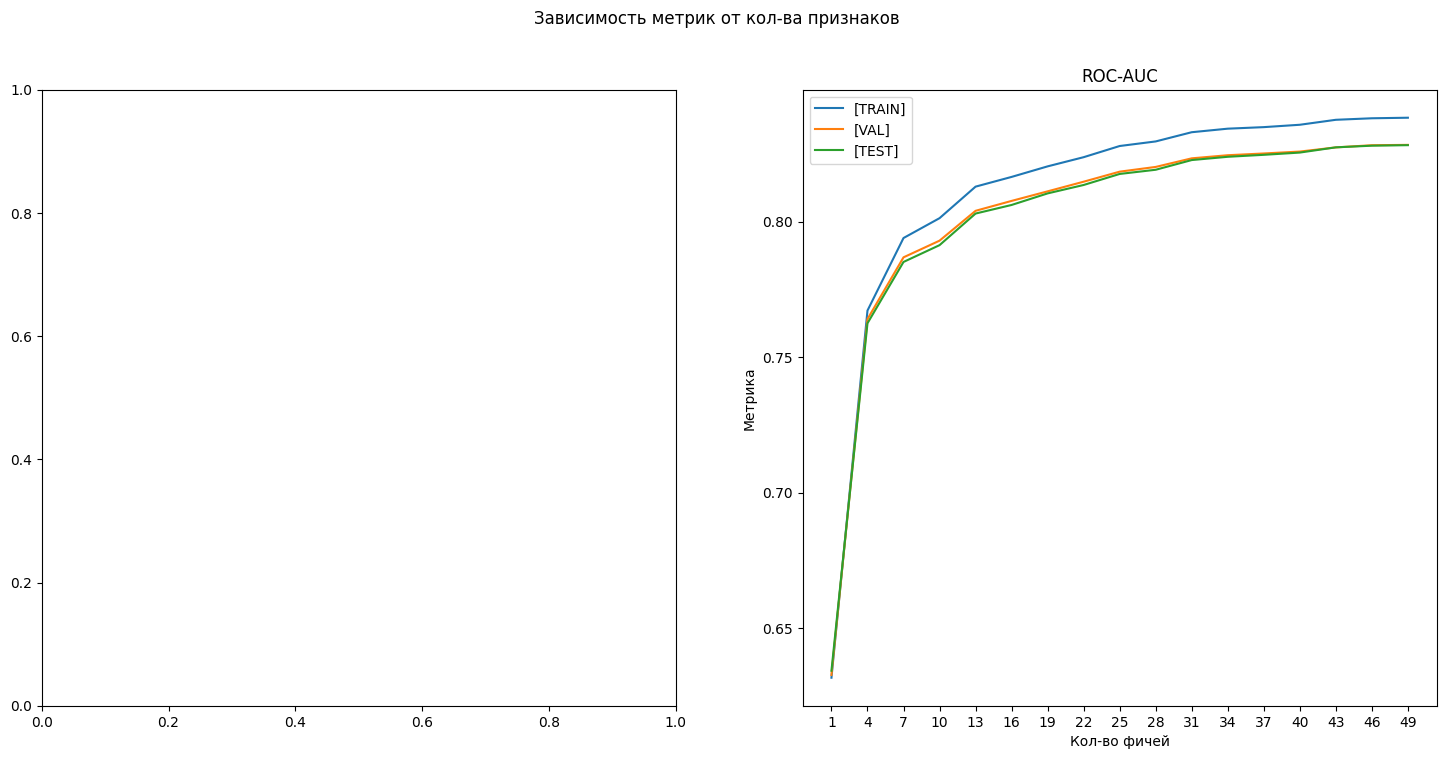

In [164]:
fig, axs = plt.subplots(ncols = 2, figsize = (18, 8), )

fig.suptitle('Зависимость метрик от кол-ва признаков')


plt.title('Метрики от кол-ва фичей')
plt.ylabel('Метрика')
plt.xlabel('Кол-во фичей')


# axs[0].plot(train_f1, label = '[TRAIN]')
# axs[0].plot(val_f1, label = '[VAL]')
# axs[0].plot(test_f1, label = '[TEST]')

# axs[0].set_title('F1')
# axs[0].set_xticks(ticks = list(range(len(train_f1))), labels = xticks)
# axs[0].set_xlabel('Кол-во фичей')
# axs[0].set_ylabel('Метрика')




axs[1].plot(train_roc_auc, label = '[TRAIN]')
axs[1].plot(val_roc_auc, label = '[VAL]')
axs[1].plot(test_roc_auc, label = '[TEST]')

axs[1].set_title('ROC-AUC')
axs[1].set_xlabel('Кол-во фичей')
axs[1].set_ylabel('Метрика')

axs[1].set_xticks(ticks = list(range(len(train_roc_auc))), labels = xticks)


axs[1].legend();

In [165]:
num_features = 31
final_features = importances[:num_features]

In [166]:
final_features

['srv_sbol_1st_txn_dt',
 'cla_dep_active_last_dt',
 'cla_da_active_last_dt',
 'seg_client_fl_segment_cd',
 'dep_acc_lst_open_dt',
 'srv_sbol_1st_login_ever_dt',
 'dep_payroll_max_dt',
 'dep_inf_new_acct_qty_sum_9_12',
 'crd_dc_lst_crd_1st_spnd_dt',
 'srv_mb_1st_txn_ever_dt',
 'crd_inf_cc_total_rub_amt_sum_6m',
 'lne_pl_max_psb_trm_mnth_qty',
 'dep_payroll_min_dt',
 'dep_inf_social_rub_amt_sum_6_9',
 'seg_age_segment',
 'crd_cc_max_issue_dt',
 'sd_russian_citizen_nflag',
 'dep_social_min_dt',
 'cla_mb_active_last_dt',
 'cla_crd_cc_active_last_dt',
 'bal_ops_amt',
 'prd_p2p_active_nflag',
 'prd_lst_prod_open_dt',
 'crd_dc_lst_open_dt',
 'srv_sbol_mob_lst_login_dt',
 'srv_sbol_mob_3m_login_nflag',
 'cla_curr_acc_active_last_dt',
 'dep_social_max_dt',
 'tp_lst_open_dt',
 'srv_sbol_web_lst_login_ever_dt',
 'lne_pl_max_close_dt']

In [167]:
final_features = ['srv_sbol_1st_txn_dt',
 'cla_dep_active_last_dt',
 'cla_da_active_last_dt',
 'seg_client_fl_segment_cd',
 'dep_acc_lst_open_dt',
 'srv_sbol_1st_login_ever_dt',
 'dep_payroll_max_dt',
 'dep_inf_new_acct_qty_sum_9_12',
 'crd_dc_lst_crd_1st_spnd_dt',
 'srv_mb_1st_txn_ever_dt',
 'crd_inf_cc_total_rub_amt_sum_6m',
 'lne_pl_max_psb_trm_mnth_qty',
 'dep_payroll_min_dt',
 'dep_inf_social_rub_amt_sum_6_9',
 'seg_age_segment',
 'crd_cc_max_issue_dt',
 'sd_russian_citizen_nflag',
 'dep_social_min_dt',
 'cla_mb_active_last_dt',
 'cla_crd_cc_active_last_dt',
 'bal_ops_amt',
 'prd_p2p_active_nflag',
 'prd_lst_prod_open_dt',
 'crd_dc_lst_open_dt',
 'srv_sbol_mob_lst_login_dt',
 'srv_sbol_mob_3m_login_nflag',
 'cla_curr_acc_active_last_dt',
 'dep_social_max_dt',
 'tp_lst_open_dt',
 'srv_sbol_web_lst_login_ever_dt',
 'lne_pl_max_close_dt']

## Last

In [209]:
x_oot = train_df.drop(columns=['epk_id', 'report_dt', 'target'])
y_oot = train_df['target']

In [210]:
text_columns = x_oot.select_dtypes(include=['object']).columns.tolist()

In [211]:
oot_pool = Pool(x_oot, y_oot, cat_features=text_columns)

In [168]:
x_train_last = x_train[final_features]
x_val_last = x_val[final_features]
x_test_last = x_test[final_features]

In [169]:
text_columns = x_train_last.select_dtypes(include=['object']).columns.tolist()

In [170]:
train_pool = Pool(x_train_last, y_train, cat_features=text_columns)
val_pool = Pool(x_val_last, y_val, cat_features=text_columns)
test_pool = Pool(x_test_last, y_test, cat_features=text_columns)

In [171]:
#text_columns_oot = train_df_oot.drop(columns='target').select_dtypes(include=['object']).columns.tolist()
#x = train_df_oot.drop(columns=['target', 'report_dt', 'epk_id'])
#y = train_df_oot['target']
#oot_pool = Pool(x, y, cat_features=text_columns_oot)

In [172]:
model = ctb.CatBoostClassifier(iterations=1000, depth=5, learning_rate = 0.1, 
                               verbose=100, task_type = 'GPU', loss_function='MultiClass', 
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass')
model.fit(train_pool, eval_set = val_pool)

0:	learn: 1.4662926	test: 1.4667914	best: 1.4667914 (0)	total: 9.97ms	remaining: 9.96s
100:	learn: 0.8859716	test: 0.8893531	best: 0.8893531 (100)	total: 882ms	remaining: 7.85s
200:	learn: 0.8665039	test: 0.8715959	best: 0.8715959 (200)	total: 1.72s	remaining: 6.84s
300:	learn: 0.8567735	test: 0.8638158	best: 0.8638158 (300)	total: 2.59s	remaining: 6.01s
400:	learn: 0.8509516	test: 0.8596464	best: 0.8596464 (400)	total: 3.4s	remaining: 5.09s
500:	learn: 0.8465974	test: 0.8570035	best: 0.8570035 (500)	total: 4.21s	remaining: 4.19s
600:	learn: 0.8433732	test: 0.8554946	best: 0.8554946 (600)	total: 5.01s	remaining: 3.33s
700:	learn: 0.8405606	test: 0.8543322	best: 0.8543322 (700)	total: 5.81s	remaining: 2.48s
800:	learn: 0.8380691	test: 0.8534749	best: 0.8534749 (800)	total: 6.63s	remaining: 1.65s
900:	learn: 0.8358839	test: 0.8528575	best: 0.8528575 (900)	total: 7.45s	remaining: 818ms
999:	learn: 0.8338262	test: 0.8523980	best: 0.8523980 (999)	total: 8.26s	remaining: 0us
bestTest = 0.852

In [212]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"OOT : {roc_auc_score(y_oot, model.predict_proba(oot_pool), multi_class = 'ovr', average = 'weighted')}")

TRAIN : 0.8500903758663068
VAL : 0.8440094015496447
TEST : 0.8435972657054661
OOT : 0.8054141499186408


In [213]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'macro')}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'macro')}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'macro')}")
print(f"OOT : {roc_auc_score(y_oot, model.predict_proba(oot_pool), multi_class = 'ovr', average = 'macro')}")

TRAIN : 0.8330377194222756
VAL : 0.823394747217964
TEST : 0.8227585254794507
OOT : 0.7913312731052967


In [174]:
print(classification_report(y_test, model.predict(test_pool)))

              precision    recall  f1-score   support

           1       0.49      0.14      0.22     15911
           2       0.57      0.57      0.57     31277
           3       0.50      0.30      0.37      7998
           4       0.37      0.04      0.07      9561
           5       0.75      0.93      0.83     95253

    accuracy                           0.70    160000
   macro avg       0.54      0.40      0.41    160000
weighted avg       0.66      0.70      0.65    160000



In [215]:
print(classification_report(y_oot, model.predict(oot_pool)))

              precision    recall  f1-score   support

           1       0.37      0.19      0.25    211664
           2       0.61      0.82      0.70    577935
           3       0.44      0.39      0.41     95559
           4       0.26      0.06      0.10     93884
           5       0.69      0.68      0.69    607657

    accuracy                           0.61   1586699
   macro avg       0.47      0.43      0.43   1586699
weighted avg       0.58      0.61      0.58   1586699



In [185]:
model.save_model('final_model_v4_new.cbm')

In [249]:
low, high = -1, 100000000

features = final_features = ['seg_crm_spec_year_qty',
'dep_inf_new_acct_qty_sum_6_9',
'dep_acc_lst_open_dt',
'dep_acct_dep_save_bal_rub_amt_sum_3_6',
'cla_da_active_last_dt',
'dep_acc_lst_close_dt',
'srv_sbol_mob_3m_login_nflag',
'prd_p2p_active_nflag',
'crd_cc_utilization_pct',
'srv_sbol_lst_login_ever_dt',
'srv_sbol_web_lst_login_ever_dt',
'dep_inf_social_rub_amt_sum_3_12',
'srv_sbol_mob_1st_login_ever_dt',
'prd_lst_prod_open_dt',
'srv_sbol_mob_1st_login_dt',
'lne_min_exp_pl_ann_dt',
'cla_crd_cc_active_last_dt',
'dep_social_min_dt',
'sd_russian_citizen_nflag',
'dep_payroll_max_dt',
'tp_1st_open_dt',
'srv_thanks_dt',
'srv_sbol_txn_web_1m_qty_sum_3_9',
'dep_pens_plus_qty_sum_3_6',
'dep_otf_intr_pmt_qty_sum_3m',
'srv_ap_cnbx_qty',
'crd_cc_lst_os_amt',
'dep_upr_tot_bal_rub_amt']
                                                                          
                                                                          
means = {}

for feat in final_features:
    s = final_df[feat].where(final_df[feat].gt(low) & final_df[feat].lt(high))
    
    means[feat] = s.groupby(final_df['target']).mean()

result = pd.DataFrame(means)

In [250]:
result

,seg_crm_spec_year_qty,dep_inf_new_acct_qty_sum_6_9,dep_acc_lst_open_dt,dep_acct_dep_save_bal_rub_amt_sum_3_6,cla_da_active_last_dt,dep_acc_lst_close_dt,srv_sbol_mob_3m_login_nflag,prd_p2p_active_nflag,crd_cc_utilization_pct,srv_sbol_lst_login_ever_dt,srv_sbol_web_lst_login_ever_dt,dep_inf_social_rub_amt_sum_3_12,srv_sbol_mob_1st_login_ever_dt,prd_lst_prod_open_dt,srv_sbol_mob_1st_login_dt,lne_min_exp_pl_ann_dt,cla_crd_cc_active_last_dt,dep_social_min_dt,sd_russian_citizen_nflag,dep_payroll_max_dt,tp_1st_open_dt,srv_thanks_dt,srv_sbol_txn_web_1m_qty_sum_3_9,dep_pens_plus_qty_sum_3_6,dep_otf_intr_pmt_qty_sum_3m,srv_ap_cnbx_qty,crd_cc_lst_os_amt,dep_upr_tot_bal_rub_amt
target,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.131615,1.043524,472.540898,1.154293,38.429552,615.916090,0.707799,0.684310,0.247718,24.837162,189.879131,1.108247,2126.073286,276.478240,27.590690,1398.382609,456.380143,3185.135795,0.990391,556.576501,1165.275398,2200.568139,1.005592,0.995548,130.514885,0.189402,93621.851904,33790.015551
2,0.118156,1.006127,430.086349,1.136511,35.573461,577.509606,0.936892,0.943227,0.185620,4.449692,314.379423,1.115268,2396.082162,248.533072,28.179173,1708.358491,549.487866,2542.936959,0.993194,343.695402,1328.114276,2447.457422,0.932706,0.988657,202.272385,0.193727,100262.140932,45873.268047
3,0.148279,1.046906,660.074271,1.149813,38.312177,681.962687,0.388537,0.372066,0.222806,58.313044,157.794836,1.069612,1781.168029,380.338239,26.399032,1375.452830,600.034678,3498.746353,0.991029,876.701343,1019.570081,1904.880265,1.020674,0.998434,52.430017,0.106523,77337.196218,26449.073341
4,0.125723,0.995898,1177.322646,1.081943,118.405909,1176.074011,0.900452,0.882948,0.278589,12.212786,321.238668,1.089154,2330.249431,511.716575,27.622834,1399.714286,477.223913,2673.127645,0.985711,438.753641,1110.986394,2239.206680,0.965747,0.994742,30.935327,0.146032,141096.006947,27618.398000
5,0.126012,0.997588,2005.476773,1.129572,178.047747,1716.725512,0.751537,0.757964,0.400869,39.486056,311.534911,1.122254,2299.455364,918.749014,28.131024,1352.186630,264.867225,2633.457918,0.927133,489.736790,655.092360,2119.732070,1.013810,0.997303,17.012704,0.267626,119346.174377,12866.702797


In [177]:
percentiles = [0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

In [178]:
X = x_test_last
y_true = pd.Series(y_test).astype(str).str.strip().to_numpy()
proba = model.predict_proba(X)
classes = pd.Series(model.classes_).astype(str).str.strip().to_numpy()

y_true = y_true.astype(int)
classes = classes.astype(int)

rows_new = []
results_df_new = []
n = len(y_true)

In [179]:
for i, cls in enumerate(classes):
    y_score = proba[:, i]
    y_bin = (y_true == cls).astype(int)
    
    print(f"class {repr(cls)}positives:", int(y_bin.sum()))
    
    if y_bin.sum() == 0:
        continue
    
    base_rate = y_bin.mean()
    
    for p in percentiles:
        k = max(1, int(n*p))
        idx = np.argsort(y_score)[-k:]
        
        y_pred = np.zeros(n, dtype=int)
        y_pred[idx] = 1
        
        n_samples = k
    
        precision = precision_score(y_bin, y_pred, zero_division=0)
        recall = recall_score(y_bin, y_pred, zero_division=0)
        f1 = 2 * ((precision*recall)/(precision+recall))
        lift = precision/base_rate if base_rate > 0 else np.nan
    
        rows_new.append({
            'Class': cls,
            'Share': p * 100,
            'Subsample': n_samples,
            'Precision': precision,
            'Recall': recall,
            'F1_score':f1,
            'Min_score': np.min(y_score[idx]),
            'Lift': lift
        })
        # break
    
results_df_new = pd.DataFrame(rows_new)

class 1positives: 15911
class 2positives: 31277
class 3positives: 7998
class 4positives: 9561
class 5positives: 95253


In [180]:
results_df_new

,Class,Share,Subsample,Precision,Recall,F1_score,Min_score,Lift
0,1,1.0,1600,0.670625,0.067438,0.122552,0.497018,6.743762
1,1,3.0,4800,0.506667,0.152850,0.234851,0.369659,5.095008
2,1,5.0,8000,0.443500,0.222990,0.296767,0.313243,4.459808
3,1,10.0,16000,0.356875,0.358871,0.357870,0.235822,3.588712
4,1,20.0,32000,0.274156,0.551380,0.366221,0.154951,2.756898
...,...,...,...,...,...,...,...,...
60,5,60.0,96000,0.817271,0.823680,0.820463,0.575362,1.372800
61,5,70.0,112000,0.772634,0.908475,0.835066,0.426340,1.297822
62,5,80.0,128000,0.718758,0.965859,0.824186,0.255205,1.207324
63,5,90.0,144000,0.656910,0.993092,0.790753,0.100458,1.103436


In [181]:
results_df_new[results_df_new['Class'] == 1] # Сурен сказал 20%

,Class,Share,Subsample,Precision,Recall,F1_score,Min_score,Lift
0,1,1.0,1600,0.670625,0.067438,0.122552,0.497018,6.743762
1,1,3.0,4800,0.506667,0.152850,0.234851,0.369659,5.095008
2,1,5.0,8000,0.443500,0.222990,0.296767,0.313243,4.459808
3,1,10.0,16000,0.356875,0.358871,0.357870,0.235822,3.588712
4,1,20.0,32000,0.274156,0.551380,0.366221,0.154951,2.756898
5,1,30.0,48000,0.225521,0.680347,0.338752,0.112496,2.267823
6,1,40.0,64000,0.193250,0.777324,0.309544,0.083463,1.943310
7,1,50.0,80000,0.168750,0.848470,0.281511,0.061839,1.696939
8,1,60.0,96000,0.150062,0.905411,0.257455,0.045844,1.509019
9,1,70.0,112000,0.134098,0.943938,0.234835,0.033361,1.348483


In [182]:
results_df_new[results_df_new['Class'] == 2]

,Class,Share,Subsample,Precision,Recall,F1_score,Min_score,Lift
13,2,1.0,1600,0.804375,0.041148,0.078292,0.788785,4.114845
14,2,3.0,4800,0.775208,0.118969,0.206281,0.721849,3.965640
15,2,5.0,8000,0.753125,0.192634,0.306795,0.671053,3.852671
16,2,10.0,16000,0.687937,0.351920,0.465639,0.551418,3.519199
17,2,20.0,32000,0.570750,0.583943,0.577271,0.362162,2.919717
18,2,30.0,48000,0.476771,0.731688,0.577343,0.236949,2.438959
19,2,40.0,64000,0.406766,0.832337,0.546470,0.154123,2.080842
20,2,50.0,80000,0.351100,0.898040,0.504830,0.102840,1.796080
21,2,60.0,96000,0.306667,0.941267,0.462613,0.070389,1.568778
22,2,70.0,112000,0.270455,0.968475,0.422831,0.046874,1.383536


In [183]:
results_df_new[results_df_new['Class'] == 3]

,Class,Share,Subsample,Precision,Recall,F1_score,Min_score,Lift
26,3,1.0,1600,0.589375,0.117904,0.196499,0.517711,11.790448
27,3,3.0,4800,0.495417,0.297324,0.371621,0.360010,9.910811
28,3,5.0,8000,0.418125,0.418230,0.418177,0.225260,8.364591
29,3,10.0,16000,0.284313,0.568767,0.379115,0.094904,5.687672
30,3,20.0,32000,0.175594,0.702551,0.280964,0.046150,3.512753
31,3,30.0,48000,0.129792,0.778945,0.222508,0.033531,2.596482
32,3,40.0,64000,0.105266,0.842336,0.187144,0.025663,2.105839
33,3,50.0,80000,0.088475,0.884971,0.160867,0.020440,1.769942
34,3,60.0,96000,0.076844,0.922356,0.141868,0.016561,1.537259
35,3,70.0,112000,0.067714,0.948237,0.126402,0.013331,1.354624


In [184]:
results_df_new[results_df_new['Class'] == 4]

,Class,Share,Subsample,Precision,Recall,F1_score,Min_score,Lift
39,4,1.0,1600,0.365625,0.061186,0.104829,0.315716,6.118607
40,4,3.0,4800,0.293125,0.147160,0.195947,0.234645,4.905345
41,4,5.0,8000,0.258750,0.216505,0.235750,0.196157,4.330091
42,4,10.0,16000,0.215312,0.360318,0.269551,0.143366,3.603180
43,4,20.0,32000,0.166313,0.556636,0.256105,0.092350,2.783182
44,4,30.0,48000,0.138083,0.693233,0.230295,0.065881,2.310776
45,4,40.0,64000,0.117859,0.788934,0.205081,0.049935,1.972336
46,4,50.0,80000,0.103100,0.862671,0.184187,0.038413,1.725343
47,4,60.0,96000,0.091042,0.914130,0.165591,0.029040,1.523551
48,4,70.0,112000,0.081152,0.950633,0.149538,0.021087,1.358047


In [136]:
results_df_new[results_df_new['Class'] == 5]

,Class,Share,Subsample,Precision,Recall,F1_score,Min_score,Lift
52,5,1.0,1600,0.976250,0.016398,0.032255,0.965070,1.639843
53,5,3.0,4800,0.970417,0.048901,0.093111,0.954712,1.630045
54,5,5.0,8000,0.966125,0.081142,0.149710,0.945829,1.622836
55,5,10.0,16000,0.953937,0.160236,0.274384,0.923478,1.602364
56,5,20.0,32000,0.932906,0.313407,0.469191,0.883997,1.567037
57,5,30.0,48000,0.910271,0.458705,0.610012,0.836514,1.529016
58,5,40.0,64000,0.884797,0.594490,0.711158,0.780209,1.486226
59,5,50.0,80000,0.854888,0.717993,0.780483,0.699443,1.435986
60,5,60.0,96000,0.820583,0.827019,0.823788,0.581506,1.378364
61,5,70.0,112000,0.775830,0.912234,0.838521,0.424547,1.303191


## Optuna

In [24]:
def objective(trial):
    param = {
        "n_estimators": trial.suggest_int('n_estimators', 100, 2000),
        "learning_rate": trial.suggest_float('learning_rate', 0.01, 0.2),
        "depth": trial.suggest_int("depth", 3, 10),
        "l2_leaf_reg": trial.suggest_loguniform("l2_leaf_reg", 1e-2, 10),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.01, 1.0),
        "min_child_samples": trial.suggest_float("min_child_samples", 100, 1000, step=100),
        "grow_policy": trial.suggest_categorical("grow_policy", ['SymmetricTree', 'Depthwise', 'Lossguide']),
        "border_count": trial.suggest_categorical("border_count", [128, 256, 512, 1024]),
        "auto_class_weights": trial.suggest_categorical("auto_class_weights", [None, 'Balanced', 'SqrtBalanced'])
    }
    
    acw = trial.suggest_categorical("auto_class_weights", [None, 'Balanced', 'SqrtBalanced'])
    if acw is not None:
        param['auto_class_weights'] = acw
    
    
    model = CatBoostClassifier(**param, verbose=False, loss_function='MultiClass', 
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass',  cat_features = text_columns)
        
    model.fit(train_pool, eval_set = val_pool, early_stopping_rounds=50, plot=False)
    
    val_roc_auc = roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'macro')
    
    train_roc_auc = roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'macro')
    
    if train_roc_auc - val_roc_auc > 0.02:
        return 0
    else:
        return val_roc_auc

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=150)

In [60]:
x_oot = final_df_oot.drop(columns=['epk_id', 'report_dt', 'target'])
y_oot = final_df_oot['target']

In [61]:
text_columns = x_oot.select_dtypes(include=['object']).columns.tolist()

In [62]:
oot_pool = Pool(x_oot, y_oot, cat_features=text_columns)

In [68]:
final_df_oot['target'].value_counts()

target
5    607657
2    577935
1    211664
3     95559
4     93884
Name: count, dtype: int64

In [27]:
model = ctb.CatBoostClassifier(n_estimators=x, depth=x, learning_rate = x, l2_leaf_reg=x, 
                               colsample_bylevel=x, min_child_samples=x, grow_policy='x', border_count=x,
                               auto_class_weights='x', loss_function='MultiClass', 
                               random_seed=0, early_stopping_rounds=30, eval_metric='MultiClass')
model.fit(train_pool, eval_set = val_pool)

0:	learn: 1.5101231	test: 1.5102979	best: 1.5102979 (0)	total: 380ms	remaining: 10m 48s
1:	learn: 1.4388691	test: 1.4390643	best: 1.4390643 (1)	total: 791ms	remaining: 11m 13s
2:	learn: 1.3945810	test: 1.3946841	best: 1.3946841 (2)	total: 1.16s	remaining: 10m 59s
3:	learn: 1.3533909	test: 1.3534423	best: 1.3534423 (3)	total: 1.53s	remaining: 10m 51s
4:	learn: 1.3219963	test: 1.3220351	best: 1.3220351 (4)	total: 1.9s	remaining: 10m 45s
5:	learn: 1.2963405	test: 1.2964096	best: 1.2964096 (5)	total: 2.19s	remaining: 10m 20s
6:	learn: 1.2754584	test: 1.2755386	best: 1.2755386 (6)	total: 2.54s	remaining: 10m 16s
7:	learn: 1.2564054	test: 1.2565203	best: 1.2565203 (7)	total: 2.88s	remaining: 10m 11s
8:	learn: 1.2426725	test: 1.2428244	best: 1.2428244 (8)	total: 3.21s	remaining: 10m 5s
9:	learn: 1.2296991	test: 1.2298985	best: 1.2298985 (9)	total: 3.52s	remaining: 9m 57s
10:	learn: 1.2198553	test: 1.2200467	best: 1.2200467 (10)	total: 3.92s	remaining: 10m 4s
11:	learn: 1.2110532	test: 1.21126

In [63]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'macro')}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'macro')}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'macro')}")
print(f"OOT : {roc_auc_score(y_oot, model.predict_proba(oot_pool), multi_class = 'ovr', average = 'macro')}")

TRAIN : 0.8528236279095619
VAL : 0.8377958097453657
TEST : 0.8362499733037658
OOT : 0.5747763208801375


In [64]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'micro')}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'micro')}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'micro')}")
print(f"OOT : {roc_auc_score(y_oot, model.predict_proba(oot_pool), multi_class = 'ovr', average = 'micro')}")

TRAIN : 0.8643170443162866
VAL : 0.8515634337651133
TEST : 0.8505115780354651
OOT : 0.6267732759999823


In [67]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"OOT : {roc_auc_score(y_oot, model.predict_proba(oot_pool), multi_class = 'ovr', average = 'weighted')}")

TRAIN : 0.8508341268845945
VAL : 0.8364430024380619
TEST : 0.8348712322371888
OOT : 0.5785486236951395


In [36]:
print(classification_report(y_test, model.predict(test_pool)))

              precision    recall  f1-score   support

           1       0.48      0.24      0.32     29803
           2       0.63      0.67      0.65     60108
           3       0.59      0.61      0.60     30072
           4       0.52      0.63      0.57     54226
           5       0.53      0.51      0.52     29904

    accuracy                           0.56    204113
   macro avg       0.55      0.53      0.53    204113
weighted avg       0.56      0.56      0.55    204113

